# Kaggle Competition: House Prices: Advanced Regression Techniques

El objetivo de [esta competición](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview) es **predecir el precio de las casas** en Ames, Iowa, utilizando un conjunto de datos de entrenamiento que contiene 79 variables. La métrica de evaluación es el **error cuadrático medio** (RMSE).

![image](https://www.kaggle.com/competitions/5407/images/header)


## 1. Cargar los datos

Como siempre en un proyecto de Machine Learning, lo primero que debemos hacer es cargar los datos. Para ello, seguiremos los siguientes pasos:

1. Darnos de alta en la plataforma de [Kaggle](https://www.kaggle.com/)
2. [Registrarnos en la competición](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview).
3. Descargar los datos. Para ello nos dirigimos a la pestaña `Data` y descargamos el zip con los archivos: `train.csv`, `test.csv`, `data_description.txt` y `sample_submission.csv`, 
4. Los colocamos dentro de una carpeta llamada `data` en la raíz del proyecto. Recuerda que no subimos los datos a GitHub.
5. Cargamos los datos en un DataFrame de pandas.

In [1]:
import pandas as pd


TRAIN_CSV = '../data/house-prices/train.csv'
TEST_CSV = '../data/house-prices/test.csv'


train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
all_data_df = pd.concat([train_df, test_df], keys=['train', 'test']) #* Esto nos permite trabajar con ambos a la vez, pero tambien nos ayuda a separarlos
all_data_df.head()

Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
train 0   1          60       RL         65.0     8450   Pave   NaN      Reg   
      1   2          20       RL         80.0     9600   Pave   NaN      Reg   
      2   3          60       RL         68.0    11250   Pave   NaN      IR1   
      3   4          70       RL         60.0     9550   Pave   NaN      IR1   
      4   5          60       RL         84.0    14260   Pave   NaN      IR1   

        LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal  \
train 0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   

        MoSold YrSold  SaleType  SaleCondition  SalePrice  
train 0      2   2008        WD         Normal   208500.0  
      1      5   2007        WD         Normal   181500.0  
      2      9   2008        WD         Normal   223500.0  
      3      2   2006        WD        Abnorml   140000.0  
      4     12   2008        WD         Normal   250000.0  

[5 rows x 81 columns]

Para este ejercicio vamos a simplificar el problema y vamos a reducir el número de variables a utilizar a un set de 10 variables más manejables.

| **Nombre**        | **Descripción**                                                                                                   | **Valoración**                                                                                                                                                                     |
|---------------|---------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **OverallQual**   | Calificación de la calidad general de los materiales y acabados (1 a 10).                                     | Es crucial para la predicción del precio, ya que la calidad de construcción y acabados afecta directamente la percepción de valor y atractivo de la propiedad.                   |
| **GrLivArea**     | Área habitable sobre el nivel del suelo en pies cuadrados.                                                    | Un mayor espacio habitable es más deseable y puede alojar a más personas, incrementando la utilidad y valor de la casa.                                                        |
| **Neighborhood**  | Vecindario dentro de los límites de la ciudad de Ames.                                                        | La ubicación puede influir en la seguridad, acceso a servicios, escuelas y otros factores que afectan la calidad de vida, siendo un factor clave en el valor de la propiedad.    |
| **YearBuilt**     | Año de construcción de la casa.                                                                               | Las casas más nuevas suelen tener instalaciones modernas y menos problemas de mantenimiento, lo cual puede elevar el precio de la propiedad.                                   |
| **GarageCars**    | Capacidad del garaje en términos de número de coches.                                                         | Es un indicador de conveniencia y almacenamiento adicional, factores valorados por los compradores, especialmente en áreas suburbanas.                                          |
| **TotalBsmtSF**   | Área total del sótano en pies cuadrados.                                                                      | Un sótano más grande puede incrementar el espacio utilizable, lo que es atractivo para los compradores y puede aumentar el valor de la propiedad.                               |
| **KitchenQual**   | Califica la calidad de la cocina (Ex a Po).                                                                   | La calidad de la cocina puede influir notablemente en la decisión de compra y la disposición a pagar más, ya que es una de las áreas más importantes de una casa.              |
| **FullBath**      | Número de baños completos sobre el nivel del suelo.                                                           | Más baños completos incrementan la comodidad y funcionalidad de la vivienda, especialmente en familias numerosas, siendo un aspecto muy valorado.                               |
| **MSZoning**      | Clasificación general de la zona de la propiedad (Agrícola, Comercial, Residencial, etc.).                    | Afecta las regulaciones y el uso permitido de la propiedad, influyendo en su valor y en las posibilidades de desarrollo o remodelación.                                         |
| **LotArea**       | Tamaño del lote en pies cuadrados.                                                                            | Un terreno más grande puede ofrecer más privacidad, espacio para actividades al aire libre o futuras ampliaciones de la casa, aumentando su atractivo y valor.                  |
| **LotArea**       | Tamaño del lote en pies cuadrados.                                                                            | Un terreno más grande puede ofrecer más privacidad, espacio para actividades al aire libre o futuras ampliaciones de la casa, aumentando su atractivo y valor.                  |


In [2]:
selected_columns = [
    "OverallQual",
    "GrLivArea",
    "Neighborhood",
    "YearBuilt",
    "GarageCars",
    "TotalBsmtSF",
    "KitchenQual",
    "FullBath",
    "MSZoning",
    "LotArea",
    "SalePrice", # incluímos la variable objetivo
]

all_data_df = all_data_df[selected_columns]
all_data_df.head()

OverallQual  GrLivArea Neighborhood  YearBuilt  GarageCars  \
train 0            7       1710      CollgCr       2003         2.0   
      1            6       1262      Veenker       1976         2.0   
      2            7       1786      CollgCr       2001         2.0   
      3            7       1717      Crawfor       1915         3.0   
      4            8       2198      NoRidge       2000         3.0   

         TotalBsmtSF KitchenQual  FullBath MSZoning  LotArea  SalePrice  
train 0        856.0          Gd         2       RL     8450   208500.0  
      1       1262.0          TA         2       RL     9600   181500.0  
      2        920.0          Gd         2       RL    11250   223500.0  
      3        756.0          Gd         1       RL     9550   140000.0  
      4       1145.0          Gd         2       RL    14260   250000.0

## 2. Explorar los datos (EDA)

Una vez que hemos cargado los datos, el siguiente paso es explorarlos. Para ello, seguiremos los siguientes pasos:


1. Mostrar un resumen de los datos.


In [3]:
all_data_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2919 entries, ('train', 0) to ('test', 1458)
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   2919 non-null   int64  
 1   GrLivArea     2919 non-null   int64  
 2   Neighborhood  2919 non-null   object 
 3   YearBuilt     2919 non-null   int64  
 4   GarageCars    2918 non-null   float64
 5   TotalBsmtSF   2918 non-null   float64
 6   KitchenQual   2918 non-null   object 
 7   FullBath      2919 non-null   int64  
 8   MSZoning      2915 non-null   object 
 9   LotArea       2919 non-null   int64  
 10  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 303.3+ KB


2. Mostrar un resumen de los datos categóricos.


In [4]:
all_data_df.describe(include='object') #* interesante

,Neighborhood,KitchenQual,MSZoning
count,2919,2918,2915
unique,25,4,5
top,NAmes,TA,RL
freq,443,1492,2265


3. Mostrar un resumen de los datos numéricos.


In [5]:
all_data_df.describe()

,OverallQual,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,LotArea,SalePrice
count,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,2919.000000,2919.000000,1460.000000
mean,6.089072,1500.759849,1971.312778,1.766621,1051.777587,1.568003,10168.114080,180921.195890
std,1.409947,506.051045,30.291442,0.761624,440.766258,0.552969,7886.996359,79442.502883
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000,34900.000000
25%,5.000000,1126.000000,1953.500000,1.000000,793.000000,1.000000,7478.000000,129975.000000
50%,6.000000,1444.000000,1973.000000,2.000000,989.500000,2.000000,9453.000000,163000.000000
75%,7.000000,1743.500000,2001.000000,2.000000,1302.000000,2.000000,11570.000000,214000.000000
max,10.000000,5642.000000,2010.000000,5.000000,6110.000000,4.000000,215245.000000,755000.000000


4. Mostrar un resumen de los datos nulos.


In [6]:
all_data_df.isnull().sum()

OverallQual        0
GrLivArea          0
Neighborhood       0
YearBuilt          0
GarageCars         1
TotalBsmtSF        1
KitchenQual        1
FullBath           0
MSZoning           4
LotArea            0
SalePrice       1459
dtype: int64

5. Visualizar la distribución de la variable objetivo.


Text(0.5, 1.0, 'Distribución de la variable objetivo: SalePrice')

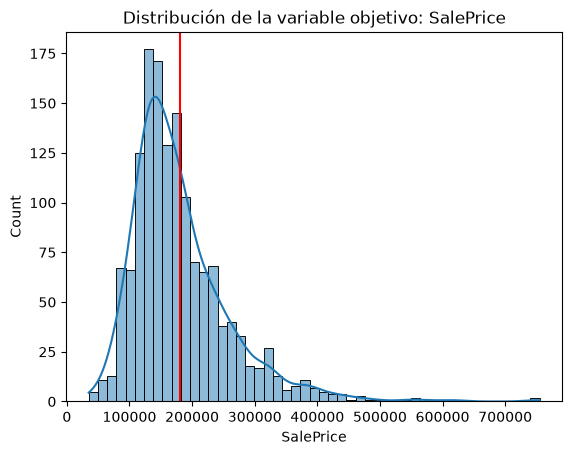

In [7]:
import seaborn as sns


y = all_data_df['SalePrice']
ax = sns.histplot(y, kde=True)
ax.axvline(y.mean(), color='red')   #*Para añadir una linea en la media
ax.set_title('Distribución de la variable objetivo: SalePrice')

#TODO: Añade la variable K y la media para que siga una weibull y eso mejore el modelo. Pero no se como se puede añadir para que el modelo conzca eso. Pregunta a chat

6. Visualizar la correlación entre las variables numéricas.


Text(0.5, 1.0, 'Matriz de correlación')

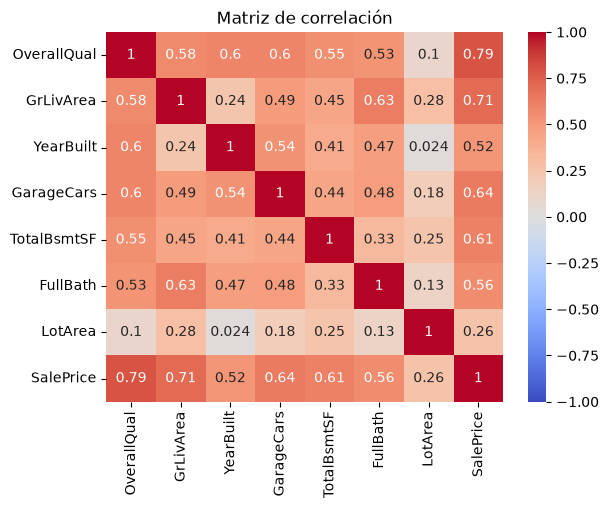

In [8]:
corr_matrix = all_data_df.corr(numeric_only=True)
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Matriz de correlación')

## 3. Preprocesamiento de los datos

Una vez que hemos explorado los datos, el siguiente paso es preprocesarlos. Para ello, seguiremos los siguientes pasos:

1. Tratar los datos nulos.
2. Codificar las variables categóricas.
3. Normalizar las variables numéricas.

In [9]:
X = all_data_df.drop(columns='SalePrice')
y = all_data_df['SalePrice']

### 3.1 Tratar los datos nulos

Vamos a ver cuantos datos nulos tenemos

In [10]:
X.isnull().sum()

OverallQual     0
GrLivArea       0
Neighborhood    0
YearBuilt       0
GarageCars      1
TotalBsmtSF     1
KitchenQual     1
FullBath        0
MSZoning        4
LotArea         0
dtype: int64

Vamos a imputar los valores nulos de las variables categóricas con la moda y los valores nulos de las variables numéricas con la media.

In [11]:
# fill GarageCars, TotalBsmtSF, MSZoning and KitchenQual with the mode

def fill_df_column_with_mode(df, column):
    mode = df[column].mode()[0]
    df[column] = df[column].fillna(mode)
    return df

X = fill_df_column_with_mode(X, 'GarageCars')
X = fill_df_column_with_mode(X, 'TotalBsmtSF')
X = fill_df_column_with_mode(X, 'MSZoning')
X = fill_df_column_with_mode(X, 'KitchenQual')

Confirmamos que no hay valores nulos.

In [12]:
X.isnull().sum()

OverallQual     0
GrLivArea       0
Neighborhood    0
YearBuilt       0
GarageCars      0
TotalBsmtSF     0
KitchenQual     0
FullBath        0
MSZoning        0
LotArea         0
dtype: int64

### 3.2 Normalizar las variables numéricas

Normalizar las variables numéricas es un paso importante en el preprocesamiento de los datos ya que permite que las variables tengan la misma escala, evitando que unas variables tengan más peso que otras en el modelo de Machine Learning. Para ello, utilizaremos el `StandardScaler` de `scikit-learn`.

El `StandardScaler` transforma las variables de forma que tengan media 0 y desviación estándar 1. Se diferencia del `MinMaxScaler` en que no transforma las variables a un rango específico, sino que las normaliza.

Veamos las variables numéricas que vamos a normalizar.

In [13]:
X.describe()

,OverallQual,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,LotArea
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,6.089072,1500.759849,1971.312778,1.766701,1051.417266,1.568003,10168.114080
std,1.409947,506.051045,30.291442,0.761506,441.120498,0.552969,7886.996359
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000
25%,5.000000,1126.000000,1953.500000,1.000000,793.000000,1.000000,7478.000000
50%,6.000000,1444.000000,1973.000000,2.000000,989.000000,2.000000,9453.000000
75%,7.000000,1743.500000,2001.000000,2.000000,1302.000000,2.000000,11570.000000
max,10.000000,5642.000000,2010.000000,5.000000,6110.000000,4.000000,215245.000000


Vamos a normalizar las variables numéricas utilizando el `StandardScaler`.

In [14]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

numeric_columns = ["GrLivArea", "YearBuilt", "TotalBsmtSF", "LotArea"]
X_numeric_df = X[numeric_columns]
X_numeric_scaled_data = scaler.fit_transform(X_numeric_df)

# keep indexes "train" and "test" to split the data later
X_numeric_scaled_df = pd.DataFrame(
    X_numeric_scaled_data,
    index=X_numeric_df.index,
    columns=X_numeric_df.columns,
)
X_numeric_scaled_df.head()

GrLivArea  YearBuilt  TotalBsmtSF   LotArea
train 0   0.413547   1.046258    -0.443078 -0.217879
      1  -0.471891   0.154764     0.477463 -0.072044
      2   0.563755   0.980221    -0.297968  0.137197
      3   0.427382  -1.859351    -0.669812 -0.078385
      4   1.378042   0.947203     0.212184  0.518903

### 3.3 Codificar las variables categóricas

Recordemos que las variables categóricas deben ser codificadas para poder ser utilizadas en un modelo de Machine Learning. Para ello, utilizaremos el `LabelEncoder` de `scikit-learn`. Primero veamos cuales son las variables categóricas.

In [15]:
from sklearn.preprocessing import LabelEncoder


def label_encode_column(df, column):
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    return df

In [16]:
X = label_encode_column(X, 'Neighborhood')
X = label_encode_column(X, 'MSZoning')
X = label_encode_column(X, 'KitchenQual')

Veamos cómo han quedado codificadas las variables categóricas.

In [17]:
categorical_columns = [
    "OverallQual",
    "GarageCars",
    "Neighborhood",
    "MSZoning",
    "KitchenQual",
    "FullBath",
]
categorical_df = X[categorical_columns]
categorical_df.head()

OverallQual  GarageCars  Neighborhood  MSZoning  KitchenQual  \
train 0            7         2.0             5         3            2   
      1            6         2.0            24         3            3   
      2            7         2.0             5         3            2   
      3            7         3.0             6         3            2   
      4            8         3.0            15         3            2   

         FullBath  
train 0         2  
      1         2  
      2         2  
      3         1  
      4         2

Ahora vamos a unir todas las variables en un solo DataFrame.

In [18]:
X_clean_df = pd.concat([X_numeric_scaled_df, categorical_df], axis=1)
X_clean_df

GrLivArea  YearBuilt  TotalBsmtSF   LotArea  OverallQual  \
train 0      0.413547   1.046258    -0.443078 -0.217879            7   
      1     -0.471891   0.154764     0.477463 -0.072044            6   
      2      0.563755   0.980221    -0.297968  0.137197            7   
      3      0.427382  -1.859351    -0.669812 -0.078385            7   
      4      1.378042   0.947203     0.212184  0.518903            8   
...               ...        ...          ...       ...          ...   
test  1454  -0.807883  -0.043346    -1.145954 -1.043937            4   
      1455  -0.807883  -0.043346    -1.145954 -1.049263            4   
      1456  -0.546995  -0.373528     0.391304  1.246808            5   
      1457  -1.049006   0.683057    -0.316107  0.034605            5   
      1458   0.986710   0.716075    -0.125650 -0.068620            7   

            GarageCars  Neighborhood  MSZoning  KitchenQual  FullBath  
train 0            2.0             5         3            2         2  
      1            2.0            24         3            3         2  
      2            2.0             5         3            2         2  
      3            3.0             6         3            2         1  
      4            3.0            15         3            2         2  
...                ...           ...       ...          ...       ...  
test  1454         0.0            10         4            3         1  
      1455         1.0            10         4            3         1  
      1456         2.0            11         3            3         1  
      1457         0.0            11         3            3         1  
      1458         3.0            11         3            3         2  

[2919 rows x 10 columns]

## 4. Split de los datos

Al estar en Kaggle y tener los datos de entrenamiento y test separados, no necesitamos dividir los datos en entrenamiento y test. Sin embargo, **vamos a dividir los datos de entrenamiento en entrenamiento y validación** para poder evaluar el rendimiento de nuestro modelo.

In [19]:
from sklearn.model_selection import train_test_split

#TODO: Idea. Haz un bucle que testee la seed de tal manera que se quede con aquella que la accuracy y precission sea la mejor

SPLIT_RATIO = 0.02
SEED = 42

#* la funcion .xs lo que hace es tomar las filas del primer indice del multiindice del dataframe
# estos son los datos limpios que usaremos para predecir y enviar a Kaggle
X_test = X_clean_df.xs('test')

# estos son los datos que usaremos para entrenar y validar nuestro modelo
X_train = X_clean_df.xs('train')
y_train = y.loc['train']

# dividimos los datos de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=SPLIT_RATIO, random_state=SEED
)

## 5. Entrenar un modelo

Una vez que hemos preprocesado los datos, el siguiente paso es entrenar un modelo. En este caso **se trata de un problema de regresión**, por lo que vamos a utilizar un modelo de regresión. En concreto, vamos a utilizar un **modelo de regresión lineal**. Este modelo se encuentra en la librería `scikit-learn` dentro de la clase `LinearRegression`.

In [20]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 24579.56, 9955.72, 9919.64,..., 57.65,-15829.8 , -4547.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['GrLivArea','YearBuilt','TotalBsmtSF',...,'MSZoning','KitchenQual', 'FullBath']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.084e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


## 6. Evaluar el modelo

Una vez que hemos entrenado el modelo, el siguiente paso es evaluarlo. Para ello, vamos a calcular el **error cuadrático medio** (RMSE) en el conjunto de validación.

In [21]:
from sklearn.metrics import root_mean_squared_error

# obtenemos las predicciones para los datos de validación
y_pred = model.predict(X_val)

# calculamos el error cuadrático medio comparando las predicciones con los valores reales
rmse = root_mean_squared_error(y_val, y_pred)
f"Mean Squared Error: {rmse:.2f}"

'Mean Squared Error: 25792.85'

## 7. Envío de los datos

Finalmente, una vez que hemos entrenado y evaluado el modelo, el último paso es predecir los precios de las casas en el conjunto de test y enviar los resultados a Kaggle para obtener la puntuación final.

¡Vamos a por ello! 🚀

El archivo `sample_submission.csv` contiene el formato en el que debemos enviar nuestras predicciones. Vamos a cargarlo para ver cómo debemos estructurar nuestros datos.

In [22]:
SAMPLE_SUBMISSION_CSV = '../data/house-prices/sample_submission.csv'
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
sample_submission_df.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


Vemos que tiene 2 columnas: `Id` y `SalePrice`. `Id` es el identificador de la casa y `SalePrice` es el precio que debemos predecir. vamos a obtener las predicciones de nuestro modelo y a guardarlas en un DataFrame con esas columnas.

In [23]:
test_predictions = model.predict(X_test)
test_ids = test_df['Id']
submission_data = {
    'Id': test_ids,
    'SalePrice': test_predictions,
}
submission_df = pd.DataFrame(submission_data)
submission_df.head()

,Id,SalePrice
0,1461,106942.409624
1,1462,171811.590484
2,1463,164511.244972
3,1464,193810.180830
4,1465,220226.244460


Guardamos las predicciones en un archivo CSV para enviar a Kaggle.

In [24]:
submission_df.to_csv('../data/house-prices/submission.csv', index=False)

# Aqui comienza mi version del modelo subida a Kaggle

In [25]:
import pandas as pd


TRAIN_CSV = '../data/house-prices/train.csv'
TEST_CSV = '../data/house-prices/test.csv'


train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
all_data_df = pd.concat([train_df, test_df], keys=['train', 'test']) #* Esto nos permite trabajar con ambos a la vez, pero tambien nos ayuda a separarlos
all_data_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [26]:
#* Vamos a añadir mas columnas que considero tambien son relevantes

selected_columns = [
    "Street",
    "Utilities",
    "OverallCond",
    "YearRemodAdd",
    "RoofStyle",
    "RoofMatl",
    "ExterQual",
    "ExterCond",
    "Heating",
    "HeatingQC",
    "CentralAir",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "PoolArea",
    "OverallQual",
    "GrLivArea",
    "Neighborhood",
    "YearBuilt",
    "GarageCars",
    "TotalBsmtSF",
    "KitchenQual",
    "FullBath",
    "MSZoning",
    "LotArea",
    "SalePrice", # incluímos la variable objetivo
]

all_data_df = all_data_df[selected_columns]
display(all_data_df.head())
display(all_data_df["PoolArea"].mean())

Street Utilities  OverallCond  YearRemodAdd RoofStyle RoofMatl  \
train 0   Pave    AllPub            5          2003     Gable  CompShg   
      1   Pave    AllPub            8          1976     Gable  CompShg   
      2   Pave    AllPub            5          2002     Gable  CompShg   
      3   Pave    AllPub            5          1970     Gable  CompShg   
      4   Pave    AllPub            5          2000     Gable  CompShg   

        ExterQual ExterCond Heating HeatingQC  ... GrLivArea  Neighborhood  \
train 0        Gd        TA    GasA        Ex  ...      1710       CollgCr   
      1        TA        TA    GasA        Ex  ...      1262       Veenker   
      2        Gd        TA    GasA        Ex  ...      1786       CollgCr   
      3        TA        TA    GasA        Gd  ...      1717       Crawfor   
      4        Gd        TA    GasA        Ex  ...      2198       NoRidge   

         YearBuilt  GarageCars  TotalBsmtSF  KitchenQual FullBath  MSZoning  \
train 0       2003         2.0        856.0           Gd        2        RL   
      1       1976         2.0       1262.0           TA        2        RL   
      2       2001         2.0        920.0           Gd        2        RL   
      3       1915         3.0        756.0           Gd        1        RL   
      4       2000         3.0       1145.0           Gd        2        RL   

         LotArea  SalePrice  
train 0     8450   208500.0  
      1     9600   181500.0  
      2    11250   223500.0  
      3     9550   140000.0  
      4    14260   250000.0  

[5 rows x 25 columns]

2.2517985611510793

In [27]:
display(all_data_df.info())
display(all_data_df.describe(include='object'))


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2919 entries, ('train', 0) to ('test', 1458)
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Street        2919 non-null   object 
 1   Utilities     2917 non-null   object 
 2   OverallCond   2919 non-null   int64  
 3   YearRemodAdd  2919 non-null   int64  
 4   RoofStyle     2919 non-null   object 
 5   RoofMatl      2919 non-null   object 
 6   ExterQual     2919 non-null   object 
 7   ExterCond     2919 non-null   object 
 8   Heating       2919 non-null   object 
 9   HeatingQC     2919 non-null   object 
 10  CentralAir    2919 non-null   object 
 11  BedroomAbvGr  2919 non-null   int64  
 12  KitchenAbvGr  2919 non-null   int64  
 13  PoolArea      2919 non-null   int64  
 14  OverallQual   2919 non-null   int64  
 15  GrLivArea     2919 non-null   int64  
 16  Neighborhood  2919 non-null   object 
 17  YearBuilt     2919 non-null   int64  
 18  GarageC

None

,Street,Utilities,RoofStyle,RoofMatl,ExterQual,ExterCond,Heating,HeatingQC,CentralAir,Neighborhood,KitchenQual,MSZoning
count,2919,2917,2919,2919,2919,2919,2919,2919,2919,2919,2918,2915
unique,2,2,6,8,4,5,6,5,2,25,4,5
top,Pave,AllPub,Gable,CompShg,TA,TA,GasA,Ex,Y,NAmes,TA,RL
freq,2907,2916,2310,2876,1798,2538,2874,1493,2723,443,1492,2265


In [28]:
X = all_data_df.drop(columns='SalePrice')
y = all_data_df['SalePrice']

display(all_data_df.isnull().sum())

Street             0
Utilities          2
OverallCond        0
YearRemodAdd       0
RoofStyle          0
RoofMatl           0
ExterQual          0
ExterCond          0
Heating            0
HeatingQC          0
CentralAir         0
BedroomAbvGr       0
KitchenAbvGr       0
PoolArea           0
OverallQual        0
GrLivArea          0
Neighborhood       0
YearBuilt          0
GarageCars         1
TotalBsmtSF        1
KitchenQual        1
FullBath           0
MSZoning           4
LotArea            0
SalePrice       1459
dtype: int64

In [29]:
# fill Utilities, GarageCars, TotalBsmtSF, MSZoning and KitchenQual with the mode

def fill_df_column_with_mode(df, column):
    mode = df[column].mode()[0]
    df[column] = df[column].fillna(mode)
    return df

X = fill_df_column_with_mode(X, 'Utilities')
X = fill_df_column_with_mode(X, 'GarageCars')
X = fill_df_column_with_mode(X, 'TotalBsmtSF')
X = fill_df_column_with_mode(X, 'MSZoning')
X = fill_df_column_with_mode(X, 'KitchenQual')

X.isnull().sum()

Street          0
Utilities       0
OverallCond     0
YearRemodAdd    0
RoofStyle       0
RoofMatl        0
ExterQual       0
ExterCond       0
Heating         0
HeatingQC       0
CentralAir      0
BedroomAbvGr    0
KitchenAbvGr    0
PoolArea        0
OverallQual     0
GrLivArea       0
Neighborhood    0
YearBuilt       0
GarageCars      0
TotalBsmtSF     0
KitchenQual     0
FullBath        0
MSZoning        0
LotArea         0
dtype: int64

In [30]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

numeric_columns = ["GrLivArea", "YearBuilt", "YearRemodAdd", "TotalBsmtSF", "LotArea", "PoolArea"]
X_numeric_df = X[numeric_columns]
X_numeric_scaled_data = scaler.fit_transform(X_numeric_df)

# keep indexes "train" and "test" to split the data later
X_numeric_scaled_df = pd.DataFrame(
    X_numeric_scaled_data,
    index=X_numeric_df.index,
    columns=X_numeric_df.columns,
)
X_numeric_scaled_df.head()

for col in X_numeric_scaled_df.columns:
    X[col] = X_numeric_scaled_df[col]
    
display(X[X_numeric_scaled_df.columns])

GrLivArea  YearBuilt  YearRemodAdd  TotalBsmtSF   LotArea  \
train 0      0.413547   1.046258      0.896833    -0.443078 -0.217879   
      1     -0.471891   0.154764     -0.395604     0.477463 -0.072044   
      2      0.563755   0.980221      0.848965    -0.297968  0.137197   
      3      0.427382  -1.859351     -0.682812    -0.669812 -0.078385   
      4      1.378042   0.947203      0.753229     0.212184  0.518903   
...               ...        ...           ...          ...       ...   
test  1454  -0.807883  -0.043346     -0.682812    -1.145954 -1.043937   
      1455  -0.807883  -0.043346     -0.682812    -1.145954 -1.049263   
      1456  -0.546995  -0.373528      0.561757     0.391304  1.246808   
      1457  -1.049006   0.683057      0.370284    -0.316107  0.034605   
      1458   0.986710   0.716075      0.466021    -0.125650 -0.068620   

            PoolArea  
train 0     -0.06315  
      1     -0.06315  
      2     -0.06315  
      3     -0.06315  
      4     -0.06315  
...              ...  
test  1454  -0.06315  
      1455  -0.06315  
      1456  -0.06315  
      1457  -0.06315  
      1458  -0.06315  

[2919 rows x 6 columns]

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

def label_encode_column(df, column):
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    return df

def OneHotEncode_column(df, column):
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = ohe.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out([column]),
        index=df.index
    )
    
    df = df.drop(columns=[column])
    
    df = pd.concat([df, encoded_df], axis=1)
    return df
    
def OrdinalEncode_column(df, column, ordinal_categories):
    oe = OrdinalEncoder(categories = ordinal_categories)
    df[column] = oe.fit_transform(df[[column]]).ravel()
    return df

#*Aplicamos one hot encoder para aquellas variables categóricas que no deberian tener un orden implicito para que asi el modelo no entienda como tal que una categoria es mejor que la otra de forma implicita

X = OneHotEncode_column(X, 'Street')
X = OneHotEncode_column(X, 'Utilities')
X = OneHotEncode_column(X, 'RoofStyle')
X = OneHotEncode_column(X, 'RoofMatl')
X = OneHotEncode_column(X, 'Heating')
X = OneHotEncode_column(X, 'CentralAir')
X = OneHotEncode_column(X, 'Neighborhood')
X = OneHotEncode_column(X, 'MSZoning')

#* Aplicamos Ordinal Encoder a aquellas columnas que SI claramente hay un orden de valor
ordinal_categories = [['Po', 'Fa', 'TA', 'Gd', 'Ex']]

X = OrdinalEncode_column(X, 'HeatingQC', ordinal_categories)
X = OrdinalEncode_column(X, 'KitchenQual', ordinal_categories)
X = OrdinalEncode_column(X, 'ExterQual', ordinal_categories)
X = OrdinalEncode_column(X, 'ExterCond', ordinal_categories)

In [32]:
X

OverallCond  YearRemodAdd  ExterQual  ExterCond  HeatingQC  \
train 0               5      0.896833        3.0        2.0        4.0   
      1               8     -0.395604        2.0        2.0        4.0   
      2               5      0.848965        3.0        2.0        4.0   
      3               5     -0.682812        2.0        2.0        3.0   
      4               5      0.753229        3.0        2.0        4.0   
...                 ...           ...        ...        ...        ...   
test  1454            7     -0.682812        2.0        2.0        3.0   
      1455            5     -0.682812        2.0        2.0        2.0   
      1456            7      0.561757        2.0        2.0        4.0   
      1457            5      0.370284        2.0        2.0        2.0   
      1458            5      0.466021        2.0        2.0        4.0   

            BedroomAbvGr  KitchenAbvGr  PoolArea  OverallQual  GrLivArea  ...  \
train 0                3             1  -0.06315            7   0.413547  ...   
      1                3             1  -0.06315            6  -0.471891  ...   
      2                3             1  -0.06315            7   0.563755  ...   
      3                3             1  -0.06315            7   0.427382  ...   
      4                4             1  -0.06315            8   1.378042  ...   
...                  ...           ...       ...          ...        ...  ...   
test  1454             3             1  -0.06315            4  -0.807883  ...   
      1455             3             1  -0.06315            4  -0.807883  ...   
      1456             4             1  -0.06315            5  -0.546995  ...   
      1457             3             1  -0.06315            5  -1.049006  ...   
      1458             3             1  -0.06315            7   0.986710  ...   

            Neighborhood_SawyerW  Neighborhood_Somerst  Neighborhood_StoneBr  \
train 0                      0.0                   0.0                   0.0   
      1                      0.0                   0.0                   0.0   
      2                      0.0                   0.0                   0.0   
      3                      0.0                   0.0                   0.0   
      4                      0.0                   0.0                   0.0   
...                          ...                   ...                   ...   
test  1454                   0.0                   0.0                   0.0   
      1455                   0.0                   0.0                   0.0   
      1456                   0.0                   0.0                   0.0   
      1457                   0.0                   0.0                   0.0   
      1458                   0.0                   0.0                   0.0   

            Neighborhood_Timber  Neighborhood_Veenker  MSZoning_C (all)  \
train 0                     0.0                   0.0               0.0   
      1                     0.0                   1.0               0.0   
      2                     0.0                   0.0               0.0   
      3                     0.0                   0.0               0.0   
      4                     0.0                   0.0               0.0   
...                         ...                   ...               ...   
test  1454                  0.0                   0.0               0.0   
      1455                  0.0                   0.0               0.0   
      1456                  0.0                   0.0               0.0   
      1457                  0.0                   0.0               0.0   
      1458                  0.0                   0.0               0.0   

            MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM  
train 0             0.0          0.0          1.0          0.0  
      1             0.0          0.0          1.0          0.0  
      2             0.0          0.0          1.0          0.0  
      3             0.0     

In [33]:
from sklearn.model_selection import train_test_split

SPLIT_RATIO = 0.02
SEED = 42

#* la funcion .xs lo que hace es tomar las filas del primer indice del multiindice del dataframe
# estos son los datos limpios que usaremos para predecir y enviar a Kaggle
X_test = X.xs('test')

# estos son los datos que usaremos para entrenar y validar nuestro modelo
X_train = X.xs('train')
y_train = y.loc['train']

# dividimos los datos de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=SPLIT_RATIO, random_state=SEED
)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

#*Linear Regression sufre si hay multilinearidad como se ha provocado por el OneHotEncoder. ridge añade una penalizacion
model = Ridge(alpha=10)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [35]:
from sklearn.metrics import root_mean_squared_error

# obtenemos las predicciones para los datos de validación
y_pred = model.predict(X_val)

# calculamos el error cuadrático medio comparando las predicciones con los valores reales
rmse = root_mean_squared_error(y_val, y_pred)
f"Mean Squared Error: {rmse:.2f}"

'Mean Squared Error: 19929.43'

### Envio de datos

In [36]:
SAMPLE_SUBMISSION_CSV = '../data/house-prices/sample_submission.csv'
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
sample_submission_df.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [37]:
test_predictions = model.predict(X_test)
test_ids = test_df['Id']
submission_data = {
    'Id': test_ids,
    'SalePrice': test_predictions,
}
submission_df = pd.DataFrame(submission_data)
submission_df.head()

,Id,SalePrice
0,1461,108918.008369
1,1462,171317.272641
2,1463,165882.776971
3,1464,190107.887236
4,1465,243896.049791


In [38]:
submission_df.to_csv('../data/house-prices/submission.csv', index=False)